In [45]:
import SensoriMotorPrediction.globals as gl
import os
import pandas as pd
import numpy as np 
import seaborn as sb
import matplotlib.pyplot as plt
from SensoriMotorPrediction.vis import plot_binned_finger_cue, plot_binned_cue
from SensoriMotorPrediction.util import anova_finger_cue
from scipy import stats
from SensoriMotorPrediction.util import fit_lm
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

In [46]:
# load data human
experiment = 'smp2'
dat_f = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'behaviour.trial.tsv'), sep='\t', )
dat_f.stimFinger = dat_f.stimFinger.map({'index': -1, 'ring': 1, 'nogo': 0})
dat_f.cue = dat_f.cue.map({'100-0%': -1, '75-25%': -.5, '50-50%': 0, '25-75%': .5, '0-100%': 1, })

# load data monkey
dat_m = pd.read_csv(os.path.join(gl.nhpDir, gl.behavDir, f'behaviour.trial.tsv'), sep='\t')
dat_m['vel_demean'] = dat_m['vel_mean'] - dat_m.groupby(['session', 'pert'])['vel_mean'].transform('mean')
corr_drive = pd.read_csv(os.path.join(gl.nhpDir, gl.behavDir, 'corrective_drive.tsv'), sep='\t')
corr_drive['vel_demean'] = corr_drive['vel_mean'] - corr_drive.groupby(['session', 'pert'])['vel_mean'].transform('mean')

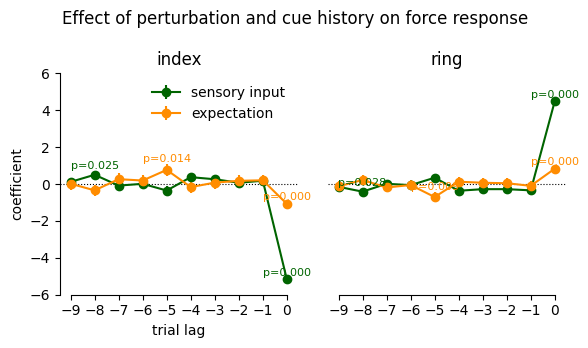

In [47]:
n_lags = 10
lags = np.arange(n_lags)
stimFinger = np.zeros((2, 10))
stimFinger_err = np.zeros_like(stimFinger)
stimFinger_p = np.zeros_like(stimFinger)
cue = np.zeros_like(stimFinger)
cue_err = np.zeros_like(stimFinger)
cue_p = np.zeros_like(stimFinger)
for lag in lags:
    dat_lag = dat_f.copy()
    dat_lag['stimFinger_lag'] = dat_lag.groupby(["BN"])["stimFinger"].shift(lag)
    dat_lag['cue_lag'] = dat_lag.groupby(["BN"])["cue"].shift(lag)
    dat_lag['GoNogo_lag'] = dat_lag.groupby(["BN"])["GoNogo"].shift(lag)
    
    dat_lag = dat_lag[(dat_lag['GoNogo_lag']=='go') & (dat_lag['GoNogo']=='go')].reset_index()

    # model
    model_index = smf.mixedlm(f"index1 ~ cue_lag + stimFinger_lag ", dat_lag, groups=dat_lag["sn"])
    model_ring = smf.mixedlm(f"ring1 ~ cue_lag + stimFinger_lag", dat_lag, groups=dat_lag["sn"])
    index = model_index.fit()
    ring = model_ring.fit()

    # index
    stimFinger[0, lag] = index.fe_params['stimFinger_lag']
    stimFinger_err[0, lag] = index.bse_fe['stimFinger_lag']
    stimFinger_p[0, lag] = index.pvalues['stimFinger_lag']
    cue[0, lag] = index.fe_params['cue_lag']
    cue_err[0, lag] = index.bse_fe['cue_lag']
    cue_p[0, lag] = index.pvalues['cue_lag']

    #ring
    stimFinger[1, lag] = ring.fe_params['stimFinger_lag']
    stimFinger_err[1, lag] = ring.bse_fe['stimFinger_lag']
    stimFinger_p[1, lag] = ring.pvalues['stimFinger_lag']
    cue[1, lag] = ring.fe_params['cue_lag']
    cue_err[1, lag] = ring.bse_fe['cue_lag']
    cue_p[1, lag] = ring.pvalues['cue_lag']

fig, axs = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(6, 3.5))

for i, ax in enumerate(axs):
    ax.errorbar(-1 * lags, stimFinger[i], yerr=stimFinger_err[i], marker='o', label='sensory input', color='darkgreen')
    ax.errorbar(-1 * lags, cue[i], yerr=cue_err[i], marker='o', label='expectation', color='darkorange')
    ax.axhline(0, lw=.8, color='k', ls=':')
    ax.set_xticks(-1 * lags)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.spines['bottom'].set_bounds(-9, 0)
    ax.tick_params(left=False)
    
    for lag in lags:
        x = -lag
        if stimFinger_p[i, lag]<.05:
            ax.text(x, stimFinger[i, lag] + stimFinger_err[i, lag], f'p={stimFinger_p[i, lag]:.03f}', ha='center', va='bottom', color='darkgreen', fontsize=8)
        if cue_p[i, lag]<.05:
            ax.text(x, cue[i, lag] + cue_err[i, lag], f'p={cue_p[i, lag]:.03f}', ha='center', va='bottom', color='darkorange', fontsize=8)

axs[0].spines[[ 'left']].set_visible(True)
axs[0].tick_params(left=True)
axs[0].set_title('index')
axs[1].set_title('ring')
axs[0].legend(frameon=False)
axs[0].set_xlabel('trial lag')
axs[0].set_ylim((-6, 6))
axs[0].set_ylabel('coefficient')
fig.suptitle('Effect of perturbation and cue history on force response')
fig.tight_layout()

plt.show()

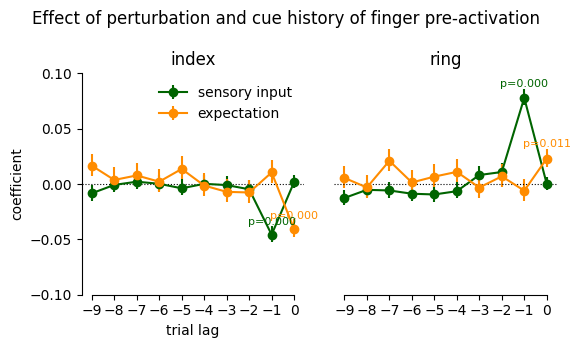

In [48]:
n_lags = 10
lags = np.arange(n_lags)
stimFinger = np.zeros((2, 10))
stimFinger_err = np.zeros_like(stimFinger)
stimFinger_p = np.zeros_like(stimFinger)
cue = np.zeros_like(stimFinger)
cue_err = np.zeros_like(stimFinger)
cue_p = np.zeros_like(stimFinger)
for lag in lags:
    dat_lag = dat_f.copy()
    dat_lag['stimFinger_lag'] = dat_lag.groupby(["BN"])["stimFinger"].shift(lag)
    dat_lag['cue_lag'] = dat_lag.groupby(["BN"])["cue"].shift(lag)
    dat_lag['GoNogo_lag'] = dat_lag.groupby(["BN"])["GoNogo"].shift(lag)
    
    dat_lag = dat_lag[(dat_lag['GoNogo_lag']=='go') & (dat_lag['GoNogo']=='go')].reset_index()

    # model
    model_index = smf.mixedlm(f"index0 ~ cue_lag + stimFinger_lag", dat_lag, groups=dat_lag["sn"])
    model_ring = smf.mixedlm(f"ring0 ~ cue_lag + stimFinger_lag", dat_lag, groups=dat_lag["sn"])
    index = model_index.fit()
    ring = model_ring.fit()

    # index
    stimFinger[0, lag] = index.fe_params['stimFinger_lag']
    stimFinger_err[0, lag] = index.bse_fe['stimFinger_lag']
    stimFinger_p[0, lag] = index.pvalues['stimFinger_lag']
    cue[0, lag] = index.fe_params['cue_lag']
    cue_err[0, lag] = index.bse_fe['cue_lag']
    cue_p[0, lag] = index.pvalues['cue_lag']

    #ring
    stimFinger[1, lag] = ring.fe_params['stimFinger_lag']
    stimFinger_err[1, lag] = ring.bse_fe['stimFinger_lag']
    stimFinger_p[1, lag] = ring.pvalues['stimFinger_lag']
    cue[1, lag] = ring.fe_params['cue_lag']
    cue_err[1, lag] = ring.bse_fe['cue_lag']
    cue_p[1, lag] = ring.pvalues['cue_lag']

fig, axs = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(6, 3.5))

for i, ax in enumerate(axs):
    ax.errorbar(-1 * lags, stimFinger[i], yerr=stimFinger_err, marker='o', label='sensory input', color='darkgreen')
    ax.errorbar(-1 * lags, cue[i], yerr=cue_err, marker='o', label='expectation', color='darkorange')
    ax.set_title(dat_f.stimFinger.unique()[i])
    ax.axhline(0, lw=.8, color='k', ls=':')
    ax.set_ylim([-.1, .1])
    ax.set_xticks(-1 * lags)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.spines['bottom'].set_bounds(-9, 0)
    ax.tick_params(left=False)
    
    for lag in lags:
        x = -lag
        if stimFinger_p[i, lag]<.05:
            ax.text(x, stimFinger[i, lag] + stimFinger_err[i, lag], f'p={stimFinger_p[i, lag]:.03f}', ha='center', va='bottom', color='darkgreen', fontsize=8)
        if cue_p[i, lag]<.05:
            ax.text(x, cue[i, lag] + cue_err[i, lag], f'p={cue_p[i, lag]:.03f}', ha='center', va='bottom', color='darkorange', fontsize=8)

axs[0].spines[[ 'left']].set_visible(True)
axs[0].tick_params(left=True)
axs[0].set_title('index')
axs[1].set_title('ring')
axs[0].legend(frameon=False)
axs[0].set_xlabel('trial lag')
axs[0].set_ylabel('coefficient')
fig.suptitle('Effect of perturbation and cue history of finger pre-activation')
fig.tight_layout()

plt.show()

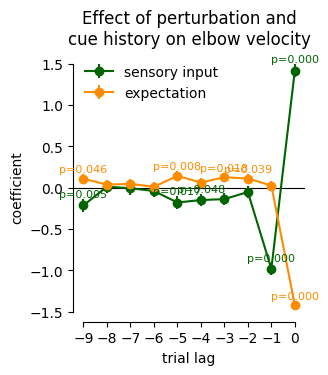

In [49]:
n_lags = 10
lags = np.arange(n_lags)
pert = np.zeros(10)
pert_err = np.zeros_like(pert)
pert_p = np.zeros_like(pert)
prob = np.zeros_like(pert)
prob_err = np.zeros_like(pert)
prob_p = np.zeros_like(pert)
for lag in lags:
    dat_lag = dat_m.copy()
    dat_lag['pert_lag'] = dat_lag.groupby(["session"])["pert"].shift(lag)
    dat_lag['prob_lag'] = dat_lag.groupby(["session"])["prob"].shift(lag)
    dat_lag = dat_lag[dat_lag['pert_lag'].isin([1, 2])].reset_index()

    # model
    model_vel_mean = smf.mixedlm(f"vel_demean ~ prob_lag + pert_lag", dat_lag, groups=dat_lag["session"])
    vel_mean = model_vel_mean.fit()

    # elbow vel
    pert[lag] = vel_mean.fe_params['pert_lag']
    pert_err[lag] = vel_mean.bse_fe['pert_lag']
    pert_p[lag] = vel_mean.pvalues['pert_lag']
    prob[lag] = vel_mean.fe_params['prob_lag']
    prob_err[lag] = vel_mean.bse_fe['prob_lag']
    prob_p[lag] = vel_mean.pvalues['prob_lag']

fig, ax = plt.subplots(figsize=(3, 3.5))

ax.errorbar(-1 * lags, pert, yerr=pert_err, marker='o', label='sensory input', color='darkgreen',)
ax.errorbar(-1 * lags, prob, yerr=prob_err, marker='o', label='expectation', color='darkorange',)
ax.axhline(0, lw=.8, color='k')
ax.set_xticks(-1 * lags)
ax.legend(frameon=False)
ax.set_ylabel('coefficient')
ax.set_xlabel('trial lag')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left']].set_bounds(-1.5, 1.5)
ax.spines[['bottom']].set_bounds(-9, 0)

for lag in lags:
    x = -lag
    if pert_p[lag]<.05:
        ax.text(x, pert[lag] + pert_err[lag], f'p={pert_p[lag]:.03f}', ha='center', va='bottom',
                color='darkgreen', fontsize=8)
    if prob_p[lag]<.05:
        ax.text(x, prob[lag] + prob_err[lag], f'p={prob_p[lag]:.03f}', ha='center', va='bottom',
                color='darkorange', fontsize=8)

ax.set_title('Effect of perturbation and\ncue history on elbow velocity')

plt.show()

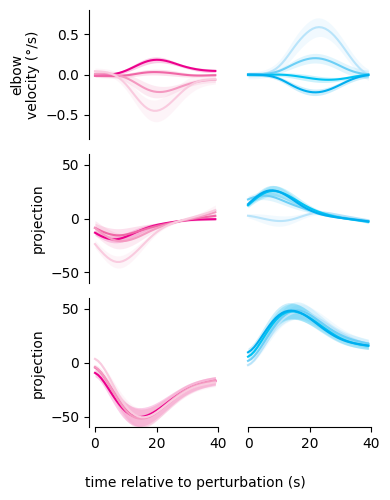

In [50]:
mapping_cond = {1: 1, 2: 8, 3: 3, 4: 6, 5: 2, 6: 5, 7: 4, 8: 7}
ylim = {0: [-.8, .8], 1: [-60, 60], 2: [-60, 60]}
ylabel = ['elbow\nvelocity (°/s)', 'projection', 'projection']
kin_list, lfp_list, spk_list = [], [], []

for mon in gl.monkey:
    for roi in ['M1']:
        for rec in gl.recordings_roi[mon][roi]:
            trial_info = pd.read_csv(os.path.join(gl.nhpDir, gl.recDir, mon, f'trial_info-{rec}.tsv'), sep='\t')
            trial_info = trial_info.loc[(trial_info.isCatch == 0) & (trial_info.AdaptationBlock == 0)].reset_index()
            trial_info.cond = trial_info.cond.map(mapping_cond)

            lfp = np.load(os.path.join(gl.nhpDir, gl.lfpDir, mon, f'corrective_drive.alpha.{roi}-{rec}.npy'))
            spk = np.load(os.path.join(gl.nhpDir, gl.spkDir, mon, f'corrective_drive.{roi}-{rec}.npy'))
            kin = np.load(os.path.join(gl.nhpDir, gl.behavDir, mon, f'kin_aligned-{rec}.npy'))[gl.pertIdx:]

            for d in [1, 2]:
                mask = trial_info.pertDirection == d
                kin[:, mask] -= kin[:, mask].mean(axis=1, keepdims=True)

            conds = np.sort(trial_info.cond.unique())
            kin_list.append([kin[:, trial_info.cond == c].mean(axis=1).squeeze() for c in conds])
            lfp_list.append([lfp[trial_info.cond == c].mean(axis=0).squeeze() for c in conds])
            spk_list.append([spk[trial_info.cond == c].mean(axis=0).squeeze() for c in conds])

kin_array = np.array(kin_list)
lfp_array = np.array(lfp_list)
spk_array = np.array(spk_list)

N = kin_array.shape[0]
means = [arr.mean(axis=0) for arr in (kin_array, lfp_array, spk_array)]
sems  = [arr.std(axis=0) / np.sqrt(N) for arr in (kin_array, lfp_array, spk_array)]

fig, axs = plt.subplots(3, 2, sharex=True, sharey='row', figsize=(4, 5))
color = list(gl.colour_mapping.values())[5:]

for c in range(8):
    col = 0 if c < 4 else 1
    ax_c = axs[:, col]
    for i, (ax, mean, sem) in enumerate(zip(ax_c, means, sems)):
        ax.plot(mean[c], color=color[c])
        ax.fill_between(np.arange(mean.shape[1]), mean[c] - sem[c], mean[c] + sem[c], color=color[c], alpha=0.2, lw=0)
        ax.set_ylim(ylim[i])
        ax.spines[['top', 'bottom', 'left', 'right']].set_visible(False)
        ax.spines['left'].set_visible(True) if col==0 else None
        ax.spines['bottom'].set_bounds(0, 40)
        ax.spines['bottom'].set_visible(True) if i==2 else None
        ax.tick_params(left=False if col==1 else True, bottom=True if i==2 else False)
        ax.set_ylabel(ylabel[i]) if col==0 else None

fig.supxlabel('time relative to perturbation (s)', fontsize=10)
fig.savefig(os.path.join('figures', 'projections.alpha.pdf'))

plt.tight_layout()

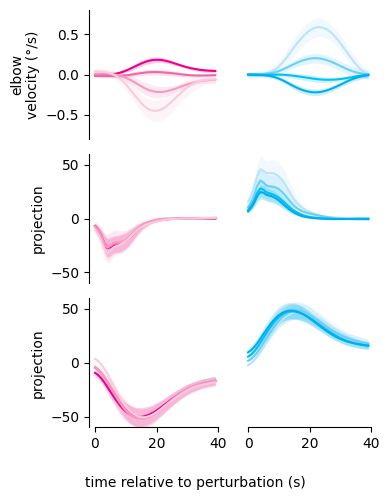

In [51]:
mapping_cond = {1: 1, 2: 8, 3: 3, 4: 6, 5: 2, 6: 5, 7: 4, 8: 7}
ylim = {0: [-.8, .8], 1: [-60, 60], 2: [-60, 60]}
ylabel = ['elbow\nvelocity (°/s)', 'projection', 'projection']
kin_list, lfp_list, spk_list = [], [], []

for mon in gl.monkey:
    for roi in ['M1']:
        for rec in gl.recordings_roi[mon][roi]:
            trial_info = pd.read_csv(os.path.join(gl.nhpDir, gl.recDir, mon, f'trial_info-{rec}.tsv'), sep='\t')
            trial_info = trial_info.loc[(trial_info.isCatch == 0) & (trial_info.AdaptationBlock == 0)].reset_index()
            trial_info.cond = trial_info.cond.map(mapping_cond)

            lfp = np.load(os.path.join(gl.nhpDir, gl.lfpDir, mon, f'corrective_drive.beta-gamma.{roi}-{rec}.npy'))
            spk = np.load(os.path.join(gl.nhpDir, gl.spkDir, mon, f'corrective_drive.{roi}-{rec}.npy'))
            kin = np.load(os.path.join(gl.nhpDir, gl.behavDir, mon, f'kin_aligned-{rec}.npy'))[gl.pertIdx:]

            for d in [1, 2]:
                mask = trial_info.pertDirection == d
                kin[:, mask] -= kin[:, mask].mean(axis=1, keepdims=True)

            conds = np.sort(trial_info.cond.unique())
            kin_list.append([kin[:, trial_info.cond == c].mean(axis=1).squeeze() for c in conds])
            lfp_list.append([lfp[trial_info.cond == c].mean(axis=0).squeeze() for c in conds])
            spk_list.append([spk[trial_info.cond == c].mean(axis=0).squeeze() for c in conds])

kin_array = np.array(kin_list)
lfp_array = np.array(lfp_list)
spk_array = np.array(spk_list)

N = kin_array.shape[0]
means = [arr.mean(axis=0) for arr in (kin_array, lfp_array, spk_array)]
sems  = [arr.std(axis=0) / np.sqrt(N) for arr in (kin_array, lfp_array, spk_array)]

fig, axs = plt.subplots(3, 2, sharex=True, sharey='row', figsize=(4, 5))
color = list(gl.colour_mapping.values())[5:]

for c in range(8):
    col = 0 if c < 4 else 1
    ax_c = axs[:, col]
    for i, (ax, mean, sem) in enumerate(zip(ax_c, means, sems)):
        ax.plot(mean[c], color=color[c])
        ax.fill_between(np.arange(mean.shape[1]), mean[c] - sem[c], mean[c] + sem[c], color=color[c], alpha=0.2, lw=0)
        ax.set_ylim(ylim[i])
        ax.spines[['top', 'bottom', 'left', 'right']].set_visible(False)
        ax.spines['left'].set_visible(True) if col==0 else None
        ax.spines['bottom'].set_bounds(0, 40)
        ax.spines['bottom'].set_visible(True) if i==2 else None
        ax.tick_params(left=False if col==1 else True, bottom=True if i==2 else False)
        ax.set_ylabel(ylabel[i]) if col==0 else None

fig.supxlabel('time relative to perturbation (s)', fontsize=10)
fig.savefig(os.path.join('figures', 'projections.beta-gamma.pdf'))

plt.tight_layout()

lag=-0, slope_alpha=-0.0006441243947655687, p_alpha=0.013019813638687346, slope_beta_gamma=0.003795826689756932, p__beta_gamma=1.4246040650104758e-06
lag=-1, slope_alpha=-0.0016977981476952542, p_alpha=5.4537086062621706e-11, slope_beta_gamma=-0.0026476350048436573, p__beta_gamma=0.0007518678973536443
lag=-2, slope_alpha=-0.0004419538436789782, p_alpha=0.08866012548649674, slope_beta_gamma=-0.0009309920465717892, p__beta_gamma=0.23725566673277365
lag=-3, slope_alpha=-0.00028858933106694384, p_alpha=0.26643295124499855, slope_beta_gamma=-0.00031728399648511693, p__beta_gamma=0.6874148818643886
lag=-4, slope_alpha=-0.0002282165332252204, p_alpha=0.37963030719697743, slope_beta_gamma=-0.0006476745947670383, p__beta_gamma=0.41152737291789754
lag=-5, slope_alpha=-0.00043841420155201166, p_alpha=0.09140873119924903, slope_beta_gamma=-0.0006284591094527039, p__beta_gamma=0.42544586007446095
lag=-6, slope_alpha=-0.00020393131460552823, p_alpha=0.43249000578629504, slope_beta_gamma=-0.000228131

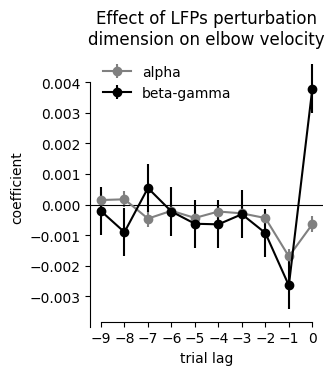

In [53]:
n_lags = 10
lags = np.arange(n_lags)
pert = np.zeros(10)
pert_err = np.zeros_like(pert)
pert_p = np.zeros_like(pert)
prob = np.zeros_like(pert)
prob_err = np.zeros_like(pert)
prob_p = np.zeros_like(pert)
lfp_alpha = np.zeros_like(pert)
lfp_alpha_err = np.zeros_like(pert)
lfp_alpha_p = np.zeros_like(pert)
lfp_beta_gamma = np.zeros_like(pert)
lfp_beta_gamma_err = np.zeros_like(pert)
lfp_beta_gamma_p = np.zeros_like(pert)
for lag in lags:
    dat_lag = corr_drive.copy()
    dat_lag['lfp_alpha_lag'] = dat_lag.groupby(["session"])["lfp_alpha"].shift(lag)
    dat_lag['lfp_beta_gamma_lag'] = dat_lag.groupby(["session"])["lfp_beta-gamma"].shift(lag)
    dat_lag = dat_lag.dropna(subset=['lfp_beta_gamma_lag']).reset_index(drop=True)

    # model
    vel_mean = smf.mixedlm(f"vel_demean ~ lfp_beta_gamma_lag + lfp_alpha_lag", dat_lag, groups=dat_lag["session"]).fit()

    lfp_alpha[lag] = vel_mean.fe_params['lfp_alpha_lag']
    lfp_alpha_err[lag] = vel_mean.bse_fe['lfp_alpha_lag']
    lfp_alpha_p[lag] = vel_mean.pvalues['lfp_alpha_lag']

    lfp_beta_gamma[lag] = vel_mean.fe_params['lfp_beta_gamma_lag']
    lfp_beta_gamma_err[lag] = vel_mean.bse_fe['lfp_beta_gamma_lag']
    lfp_beta_gamma_p[lag] = vel_mean.pvalues['lfp_beta_gamma_lag']

    print(f'lag=-{lag}, slope_alpha={lfp_alpha[lag]}, p_alpha={lfp_alpha_p[lag]}, slope_beta_gamma={lfp_beta_gamma[lag]}, p__beta_gamma={lfp_beta_gamma_p[lag]}')

fig, ax = plt.subplots(figsize=(3, 3.5))

ax.errorbar(-1 * lags, lfp_alpha, yerr=lfp_alpha_err, marker='o', label='alpha', color='gray',)
ax.errorbar(-1 * lags, lfp_beta_gamma, yerr=lfp_beta_gamma_err, marker='o', label='beta-gamma', color='k',)
ax.axhline(0, lw=.8, color='k')
ax.set_xticks(-1 * lags)
ax.legend(frameon=False)
ax.set_ylabel('coefficient')
ax.set_xlabel('trial lag')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left']].set_bounds(-.004, .004)
ax.spines[['bottom']].set_bounds(-9, 0)
#ax.set_ylim([-2, 2])

# for lag in lags:
#     x = -lag
#     if lfp_p[lag] < .05:
#         yhi = ax.get_ylim()[1]
#         y = min(lfp[lag] + lfp_err[lag], yhi * 0.95)
#         ax.text(x, y, f'p={lfp_p[lag]:.03f}', ha='center', va='bottom',
#                 color='gray', fontsize=8)

ax.set_title('Effect of LFPs perturbation\ndimension on elbow velocity')

fig.savefig(os.path.join('figures', 'carry_over.pdf'))

plt.show()